In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thuật toán học máy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Cài đặt hiển thị biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

In [16]:
pip install kagglehub

In [17]:
import kagglehub
import os

# Download the dataset using kagglehub
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

# Construct the full path to the CSV file within the downloaded dataset
# Assuming the CSV file is directly in the downloaded directory
data_file_path = os.path.join(path, 'UCI_Credit_Card.csv')

# Read the data using the correct path
df = pd.read_csv(data_file_path)

# Display the first 5 rows
display(df.head())

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [18]:
# Đọc data (Sử dụng đường dẫn đã được tải xuống từ kagglehub)
df = pd.read_csv(data_file_path)

# Xem 5 dòng đầu tiên
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [19]:
# Đổi tên cột mục tiêu cho dễ hiểu (0 = Không vỡ nợ, 1 = Vỡ nợ)
df = df.rename(columns={'default.payment.next.month': 'DEFAULT'})

# Các biến hành vi tâm lý (Lịch sử thanh toán 6 tháng qua)
# -1 = Trả đúng hạn, 1 = Trễ 1 tháng, 2 = Trễ 2 tháng...
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Chuyển các giá trị âm (trả sớm) thành 0 (coi như cùng một nhóm kỷ luật tốt) để mô hình dễ học
for col in pay_cols:
    df[col] = df[col].apply(lambda x: 0 if x <= 0 else x)

# Loại bỏ cột ID vì không có ý nghĩa phân tích
df = df.drop(['ID'], axis=1)

# Tách Features (X) và Target (y)
X = df.drop('DEFAULT', axis=1)
y = df['DEFAULT']

# Chia tập Train (70%) và Test (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Kích thước tập huấn luyện:", X_train.shape)
print("Kích thước tập kiểm tra:", X_test.shape)

Kích thước tập huấn luyện: (21000, 23)
Kích thước tập kiểm tra: (9000, 23)


In [20]:
# Khởi tạo mô hình Rừng ngẫu nhiên (100 cây)
# Random Forest rất tốt để tìm ra biến nào quan trọng nhất (để chứng minh luận điểm tâm lý của bạn)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)

# Huấn luyện mô hình
rf_model.fit(X_train, y_train)

# Dự đoán trên tập test
y_pred = rf_model.predict(X_test)

# Đánh giá mô hình
print("Độ chính xác (Accuracy):", accuracy_score(y_test, y_pred))
print("\nBáo cáo phân loại:\n", classification_report(y_test, y_pred))

Độ chính xác (Accuracy): 0.8207777777777778

Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89      7040
           1       0.68      0.34      0.45      1960

    accuracy                           0.82      9000
   macro avg       0.76      0.65      0.67      9000
weighted avg       0.80      0.82      0.80      9000



/tmp/ipykernel_1938/3316918920.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')


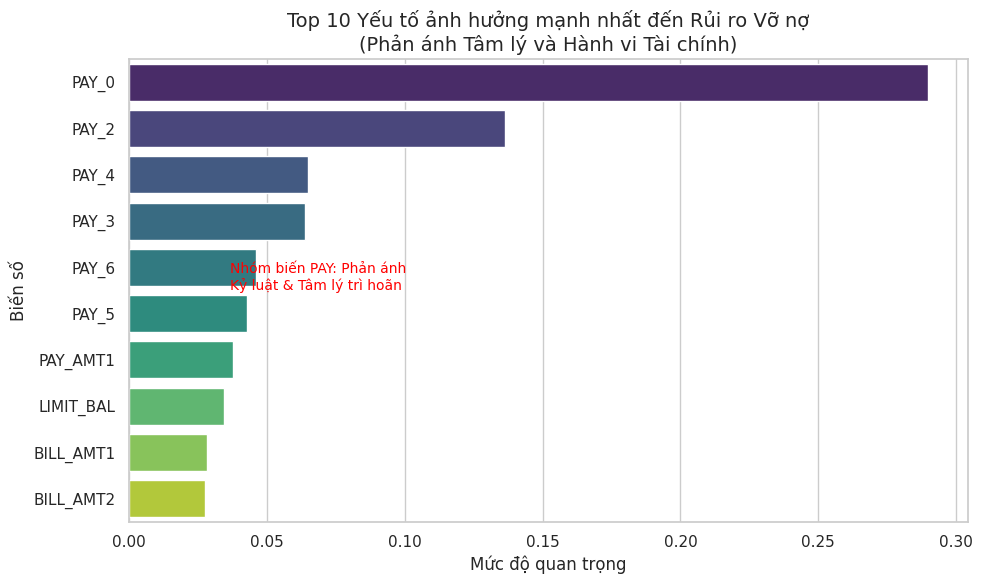

In [21]:
# Lấy mức độ quan trọng của các biến
importances = rf_model.feature_importances_

# Đưa vào DataFrame để sắp xếp
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ 10 biến quan trọng nhất
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title('Top 10 Yếu tố ảnh hưởng mạnh nhất đến Rủi ro Vỡ nợ\n(Phản ánh Tâm lý và Hành vi Tài chính)', fontsize=14)
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.ylabel('Biến số', fontsize=12)

# Ghi chú thêm vào biểu đồ để làm rõ ý nghĩa tâm lý
plt.text(0.12, 0.5, 'Nhóm biến PAY: Phản ánh\nKỷ luật & Tâm lý trì hoãn',
         fontsize=10, color='red', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

### Phân tích sâu về Tâm lý và Hành vi giữa hai nhóm (Vỡ nợ vs Không vỡ nợ)

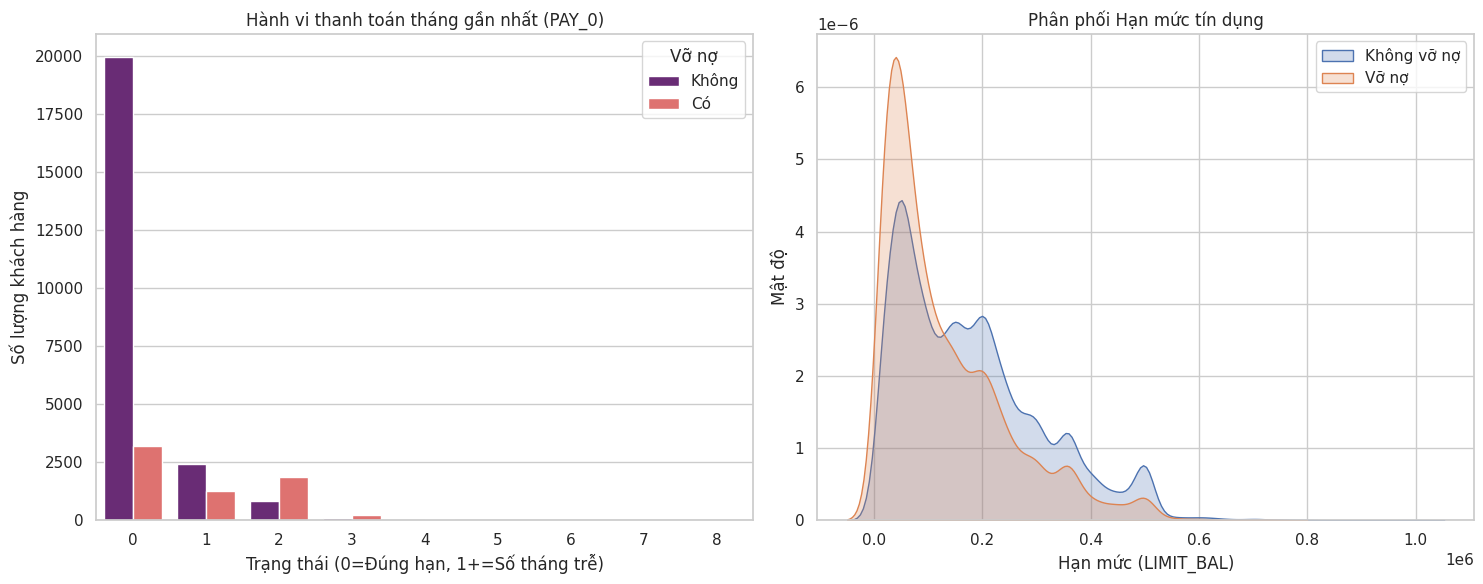

In [22]:
plt.figure(figsize=(15, 6))

# Biểu đồ 1: Tình trạng thanh toán tháng gần nhất (PAY_0)
plt.subplot(1, 2, 1)
sns.countplot(x='PAY_0', hue='DEFAULT', data=df, palette='magma')
plt.title('Hành vi thanh toán tháng gần nhất (PAY_0)', fontsize=12)
plt.xlabel('Trạng thái (0=Đúng hạn, 1+=Số tháng trễ)')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Vỡ nợ', labels=['Không', 'Có'])

# Biểu đồ 2: Phân phối hạn mức tín dụng (LIMIT_BAL)
plt.subplot(1, 2, 2)
sns.kdeplot(df.loc[(df['DEFAULT'] == 0), 'LIMIT_BAL'], label='Không vỡ nợ', fill=True)
sns.kdeplot(df.loc[(df['DEFAULT'] == 1), 'LIMIT_BAL'], label='Vỡ nợ', fill=True)
plt.title('Phân phối Hạn mức tín dụng', fontsize=12)
plt.xlabel('Hạn mức (LIMIT_BAL)')
plt.ylabel('Mật độ')
plt.legend()

plt.tight_layout()
plt.show()

**Nhận xét tâm lý:**
- **Biểu đồ PAY_0:** Nhóm vỡ nợ có tỷ lệ người trễ hạn từ 2 tháng trở lên cao vượt trội. Điều này phản ánh tâm lý trì hoãn hoặc mất khả năng kiểm soát tài chính tích tụ.
- **Biểu đồ LIMIT_BAL:** Nhóm có hạn mức thấp thường có mật độ vỡ nợ cao hơn, có thể liên quan đến tâm lý "vung tay quá trán" so với thu nhập thực tế hoặc thiếu quỹ dự phòng.

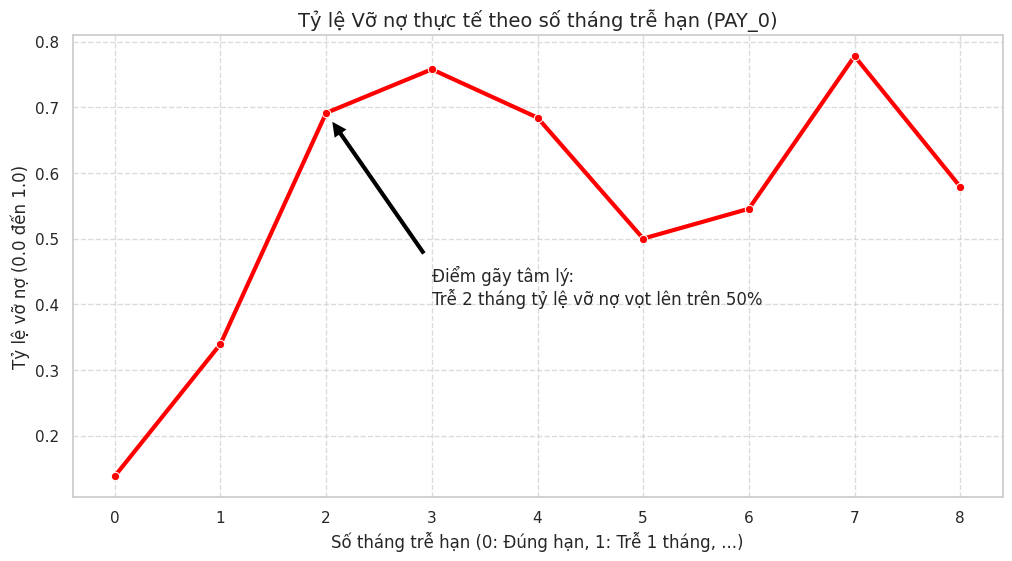

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán tỷ lệ vỡ nợ theo từng trạng thái trễ hạn
default_rate = df.groupby('PAY_0')['DEFAULT'].mean().reset_index()

plt.figure(figsize=(12, 6))

# Vẽ biểu đồ đường để thấy xu hướng tâm lý
sns.lineplot(data=default_rate, x='PAY_0', y='DEFAULT', marker='o', color='red', linewidth=3)

plt.title('Tỷ lệ Vỡ nợ thực tế theo số tháng trễ hạn (PAY_0)', fontsize=14)
plt.xlabel('Số tháng trễ hạn (0: Đúng hạn, 1: Trễ 1 tháng, ...)', fontsize=12)
plt.ylabel('Tỷ lệ vỡ nợ (0.0 đến 1.0)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Chú thích điểm gãy tâm lý
plt.annotate('Điểm gãy tâm lý:\nTrễ 2 tháng tỷ lệ vỡ nợ vọt lên trên 50%',
             xy=(2, default_rate.loc[default_rate['PAY_0']==2, 'DEFAULT'].values[0]),
             xytext=(3, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

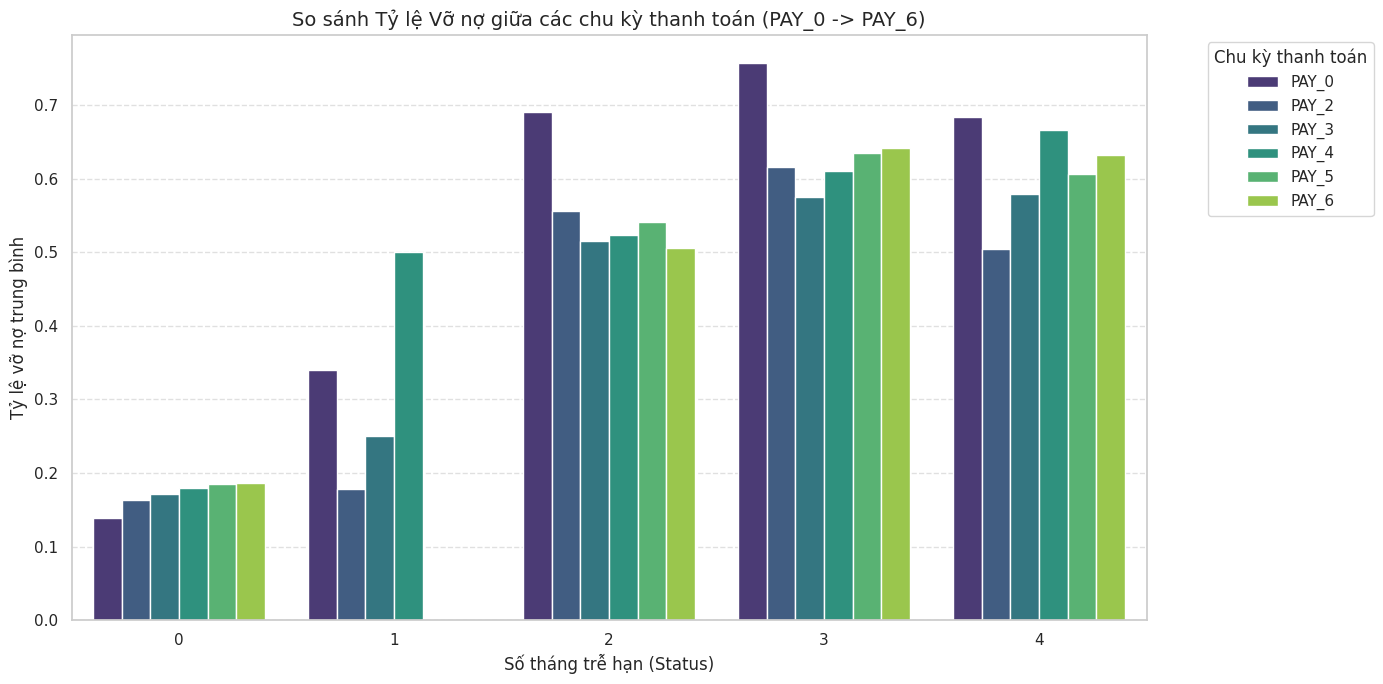

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các cột thanh toán
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Chuẩn bị dữ liệu tổng hợp
plot_data = []
for col in pay_columns:
    temp = df.groupby(col)['DEFAULT'].mean().reset_index()
    temp.columns = ['Status', 'Default_Rate']
    temp['Month'] = col
    plot_data.append(temp)

summary_df = pd.concat(plot_data)

# Chỉ lấy trạng thái từ 0 đến 4 để biểu đồ rõ ràng (vì các mốc trễ quá dài thường ít dữ liệu và gây nhiễu)
summary_df = summary_df[summary_df['Status'] <= 4]

plt.figure(figsize=(14, 7))
sns.barplot(data=summary_df, x='Status', y='Default_Rate', hue='Month', palette='viridis')

plt.title('So sánh Tỷ lệ Vỡ nợ giữa các chu kỳ thanh toán (PAY_0 -> PAY_6)', fontsize=14)
plt.xlabel('Số tháng trễ hạn (Status)', fontsize=12)
plt.ylabel('Tỷ lệ vỡ nợ trung bình', fontsize=12)
plt.legend(title='Chu kỳ thanh toán', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()